# Image Score Redistribution (New Structure)
This notebook rebalances the distribution of image scores to follow a uniform 0.0-1.0 distribution.
It helps fill gaps and ensures that your library is evenly spread across all tiers.

In [1]:
import os
import sys
from pathlib import Path

# The notebook is in external_modules/step01ranking_new/
# We need to add the plugin root (comfyui-image-scorer/) to sys.path to find 'shared'
notebook_path = Path(os.getcwd()).resolve()
plugin_root = notebook_path.parents[1]
print(f"Plugin root: {plugin_root}")

if str(plugin_root) not in sys.path:
    sys.path.insert(0, str(plugin_root))

# Also ensure the current folder is in path for relative imports
if str(notebook_path) not in sys.path:
    sys.path.insert(0, str(notebook_path))

print(f"Current working directory: {os.getcwd()}")


Plugin root: E:\ComfyUI\custom_nodes\comfyui-image-scorer
Current working directory: e:\ComfyUI\custom_nodes\comfyui-image-scorer\external_modules\step01ranking_new


In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# Import local modules
from database.images_table import get_all_images, update_image_score_confidence
from file_management.path_handler import get_ranked_root, compute_path_from_filename, find_image_path
from image_processor import ImageProcessor


In [3]:
# --- CONFIGURATION ---
UPDATE_DATABASE = False  # Set to True to save new scores to DB
MOVE_FILES = False      # Set to True to move files to new folders
DRY_RUN = True          # If True, no changes are actually made
PLOT_BINS = 100      # Number of bins for the histogram
# ---------------------


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\

Fetching images from database...


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(Font

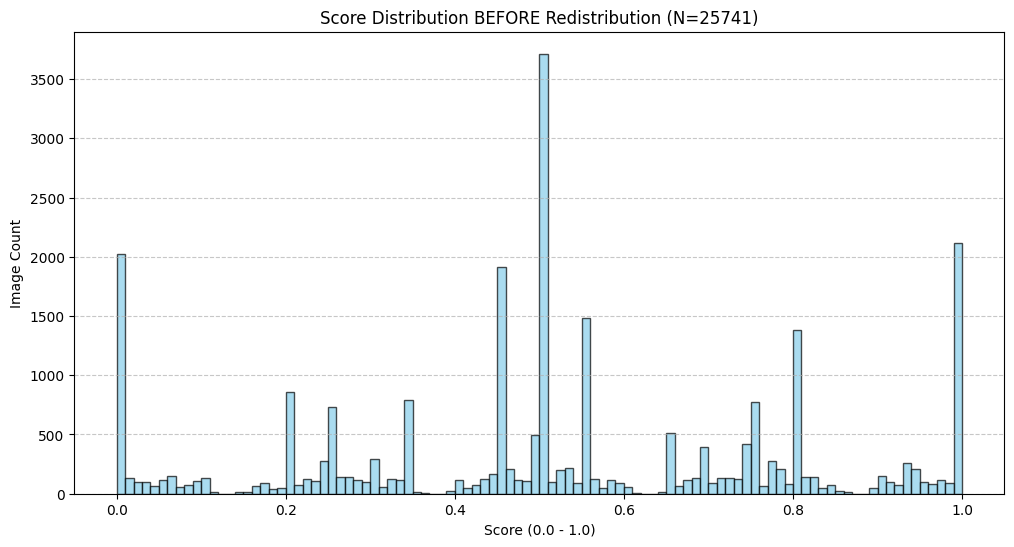

In [4]:
print("Fetching images from database...")
all_images = get_all_images()
if not all_images:
    print("No images found!")
else:
    scores = [img['score'] for img in all_images]
    plt.figure(figsize=(12, 6))
    plt.hist(scores, bins=PLOT_BINS, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"Score Distribution BEFORE Redistribution (N={len(all_images)})")
    plt.xlabel("Score (0.0 - 1.0)")
    plt.ylabel("Image Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


Calculating new uniform distribution...


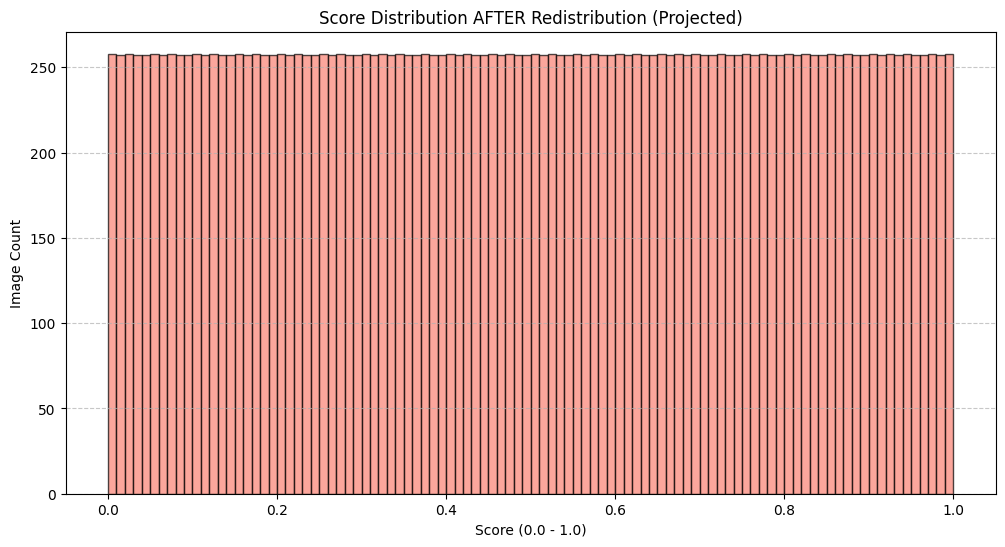

In [5]:
# Sort by current score to establish rank
all_images.sort(key=lambda x: x['score'])
total = len(all_images)
updates = []

print("Calculating new uniform distribution...")
for i, img in enumerate(all_images):
    # Map rank to 0.0-1.0 range
    if total > 1:
        new_score = i / (total - 1)
    else:
        new_score = 0.5
    
    updates.append({
        "filename": img["filename"],
        "old_score": img["score"],
        "new_score": new_score,
        "confidence": img["confidence"],
        "count": img["comparison_count"]
    })

new_scores = [up['new_score'] for up in updates]
plt.figure(figsize=(12, 6))
plt.hist(new_scores, bins=PLOT_BINS, color='salmon', edgecolor='black', alpha=0.7)
plt.title(f"Score Distribution AFTER Redistribution (Projected)")
plt.xlabel("Score (0.0 - 1.0)")
plt.ylabel("Image Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [6]:
if UPDATE_DATABASE:
    if DRY_RUN:
        print(f"[DRY RUN] Would update database scores for {len(updates)} images.")
    else:
        print(f"Updating database for {len(updates)} images...")
        for up in tqdm(updates, desc="Updating DB"):
            update_image_score_confidence(up['filename'], up['new_score'], up['confidence'], up['count'])
else:
    print("Database update skipped (UPDATE_DATABASE = False).")

if MOVE_FILES:
    moved = 0
    errors = 0
    import shutil
    
    # Instantiate processor to use its extension list
    proc = ImageProcessor()
    
    for up in tqdm(updates, desc="Relocating files"):
        current = find_image_path(up['filename'])
        if not current: 
            continue
        
        # Compute target based on the NEW score
        target = compute_path_from_filename(up['filename'], up['new_score'])
        
        if current != target:
            if DRY_RUN:
                moved += 1
            else:
                try:
                    target.parent.mkdir(parents=True, exist_ok=True)
                    # Move image
                    shutil.move(str(current), str(target))
                    # Move JSON companion
                    js = current.with_suffix('.json')
                    if js.exists(): 
                        shutil.move(str(js), str(target.with_suffix('.json')))
                    moved += 1
                except Exception as e:
                    errors += 1
    
    verb = "Would move" if DRY_RUN else "Moved"
    print(f"{verb} {moved} files. Errors: {errors}")
else:
    print("File movement skipped (MOVE_FILES = False).")


Database update skipped (UPDATE_DATABASE = False).
File movement skipped (MOVE_FILES = False).
